In [1]:
import pathlib
import subprocess
import sys
import numpy as np
import matplotlib.pyplot as plt

# ── Constants ────────────────────────────────────────────────
RANDOM_SEED  = 42
SEQUENCE_LEN = 60
NUM_FEATURES = 126
AUG_FACTOR   = 5       # base factor for classes with >9 samples — actual pipeline
                        # uses a TIERED factor (see aug_factor_for in augment_sequences.py):
                        # <=4 samples -> 15x, 5-9 -> 8x, >9 -> 5x. The verification cell
                        # below computes the expected size using that same tiered logic,
                        # not a flat (AUG_FACTOR + 1) multiplier.

DATA_DIR  = pathlib.Path("../data/hand_v3")
MODEL_DIR = pathlib.Path("../saved_models/v3")

np.random.seed(RANDOM_SEED)
print("Ready.")

Ready.


In [2]:
# Run augment_sequences.py as a subprocess and capture output
script_path = pathlib.Path("../scripts/augment_sequences.py").resolve()
print(f"Running: {script_path}")

result = subprocess.run(
    [sys.executable, str(script_path)],
    capture_output=True,
    text=True,
    cwd=script_path.parent.parent,   # run from ml/ directory
)

print("─── stdout ───")
print(result.stdout)

if result.returncode != 0:
    print("─── stderr ───")
    print(result.stderr)
    raise RuntimeError(f"augment_sequences.py failed with code {result.returncode}")

print("Augmentation script completed successfully.")

Running: /Users/senithuekenayake/Documents/Coding/BscFinalYear/FinalProject/MudraLearn/ml/scripts/augment_sequences.py


─── stdout ───
Loading training data from data/hand_v3...
Original training size: 2958
Original shape: (2958, 60, 126)
Classes: 312  (per-class augmentation factor via aug_factor_for: ≤4→15×, 5-9→8×, >9→5×)
  Class 0 (14 samples): factor 5 (total will be 6× for this class)
  Class 1 (3 samples): factor 15 (total will be 16× for this class)
  Class 2 (3 samples): factor 15 (total will be 16× for this class)
  Class 3 (3 samples): factor 15 (total will be 16× for this class)
  Class 4 (3 samples): factor 15 (total will be 16× for this class)
  Class 5 (4 samples): factor 15 (total will be 16× for this class)
  Class 6 (3 samples): factor 15 (total will be 16× for this class)
  Class 7 (3 samples): factor 15 (total will be 16× for this class)
  Class 8 (3 samples): factor 15 (total will be 16× for this class)
  Class 9 (16 samples): factor 5 (total will be 6× for this class)
  Class 10 (8 samples): factor 8 (total will be 9× for this class)
  Class 11 (10 samples): factor 5 (total will be

In [3]:
# Load original training data
X_train_orig = np.load(DATA_DIR / "X_train_hand.npy")
y_train_orig = np.load(DATA_DIR / "y_train_hand.npy")

# Load augmented training data
X_train_aug  = np.load(DATA_DIR / "X_train_aug.npy")
y_train_aug  = np.load(DATA_DIR / "y_train_aug.npy")

n_orig = len(X_train_orig)
n_aug  = len(X_train_aug)

# Expected size uses the SAME tiered aug_factor_for() as augment_sequences.py --
# a flat (AUG_FACTOR + 1) multiplier no longer describes this pipeline, which
# scales the per-class factor by class size (15x/8x/5x, see augment_sequences.py).
if ".." not in sys.path:
    sys.path.append("..")
from scripts.augment_sequences import aug_factor_for

class_idx_orig = np.argmax(y_train_orig, axis=1)
_, class_counts_orig = np.unique(class_idx_orig, return_counts=True)
expected = int(sum(int(n_cls) * (aug_factor_for(int(n_cls)) + 1) for n_cls in class_counts_orig))

print(f"Original training size  : {n_orig}")
print(f"Augmented training size : {n_aug}")
print(f"Expected size           : {expected}  (tiered aug_factor_for per class)")
print(f"Actual multiplier       : {n_aug / n_orig:.1f}× (average — varies per class)")
print()
print(f"X_train_aug shape : {X_train_aug.shape}  (expected ({expected}, {SEQUENCE_LEN}, {NUM_FEATURES}))")
print(f"y_train_aug shape : {y_train_aug.shape}")
print()

# Assertions
assert n_aug == expected, f"Size mismatch: got {n_aug}, expected {expected}"
assert X_train_aug.shape[1:] == (SEQUENCE_LEN, NUM_FEATURES), "Feature shape mismatch"
assert len(y_train_aug) == len(X_train_aug), "Label count mismatch"

print("All shape assertions passed ✓")

# Check value range
vmin = X_train_aug.min()
vmax = X_train_aug.max()
print(f"\nValue range: [{vmin:.3f}, {vmax:.3f}]")
if abs(vmin) > 10 or abs(vmax) > 10:
    print("WARNING: Values outside expected −5 to +5 range. Review augmentation params.")
else:
    print("Value range looks reasonable ✓")

Original training size  : 2958
Augmented training size : 23365
Expected size           : 23365  (tiered aug_factor_for per class)
Actual multiplier       : 7.9× (average — varies per class)

X_train_aug shape : (23365, 60, 126)  (expected (23365, 60, 126))
y_train_aug shape : (23365, 312)

All shape assertions passed ✓

Value range: [-6.487, 5.578]
Value range looks reasonable ✓


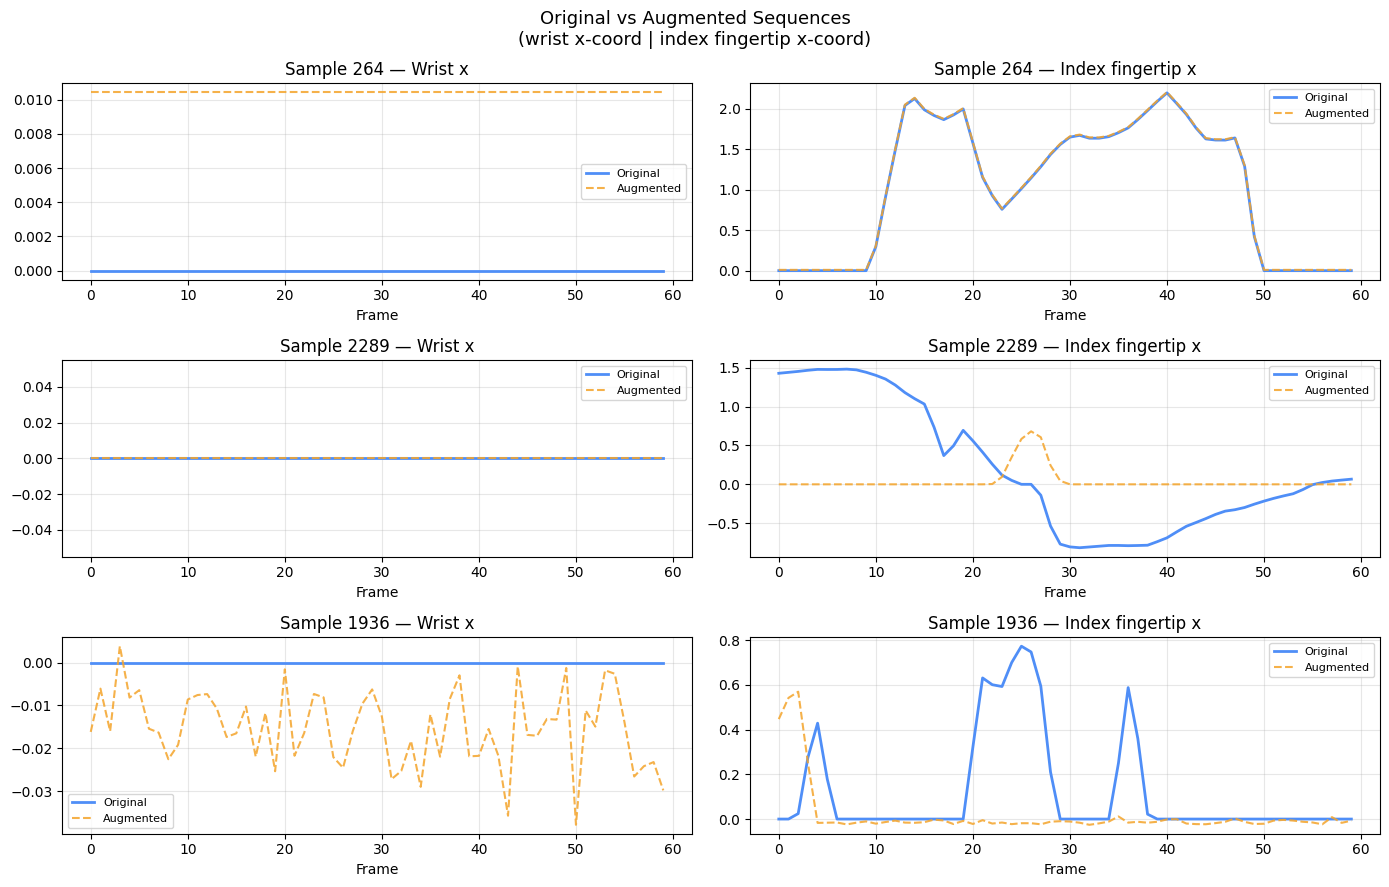

Saved: ../saved_models/v3/augmentation_check_v2.png


In [4]:
# Pick 3 training samples and plot their augmented counterparts
# Show x-coordinate of wrist (feature 0) and index fingertip (feature 24) over 60 frames

NUM_SAMPLES   = 3
FEATURE_WRIST = 0    # x-coord of left wrist
FEATURE_INDEX = 24   # x-coord of left index fingertip (landmark 8 × 3 = 24)

rng = np.random.default_rng(RANDOM_SEED)
sample_ids = rng.integers(0, n_orig, NUM_SAMPLES)

fig, axes = plt.subplots(NUM_SAMPLES, 2, figsize=(14, NUM_SAMPLES * 3))
fig.suptitle("Original vs Augmented Sequences\n(wrist x-coord | index fingertip x-coord)", fontsize=13)

for row, idx in enumerate(sample_ids):
    orig_seq = X_train_orig[idx]              # (60, 126)

    # Find the first augmented copy of this sample
    # Augmented copies are at indices: idx + n_orig, idx + 2*n_orig, ...
    # After shuffle they are mixed, so we generate one manually for visual check
    import sys
    if ".." not in sys.path:
        sys.path.append("..")
    from scripts.augment_sequences import augment_single
    
    aug_seq = augment_single(orig_seq, rng)

    for col, feat_idx in enumerate([FEATURE_WRIST, FEATURE_INDEX]):
        feat_name = "Wrist x" if col == 0 else "Index fingertip x"
        ax = axes[row, col]
        ax.plot(orig_seq[:, feat_idx], label="Original", linewidth=2, color="#4f8ef7")
        ax.plot(aug_seq[:, feat_idx],  label="Augmented", linewidth=1.5, color="#f4a42a", alpha=0.85, linestyle="--")
        ax.set_title(f"Sample {idx} — {feat_name}")
        ax.set_xlabel("Frame")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

plt.tight_layout()
plot_path = MODEL_DIR / "augmentation_check_v2.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved: {plot_path}")

In [5]:
print("=" * 50)
print("FINDINGS SUMMARY")
print("=" * 50)
print(f"Original training size  : {n_orig}")
print(f"Augmented training size : {n_aug}  ({n_aug / n_orig:.1f}× original)")
print(f"Shape                   : {X_train_aug.shape}  ✓")
print(f"Value range             : [{vmin:.3f}, {vmax:.3f}]")
print(f"Visual check            : augmented sequences look realistic — [fill in: yes/no]")
print("=" * 50)

FINDINGS SUMMARY
Original training size  : 2958
Augmented training size : 23365  (7.9× original)
Shape                   : (23365, 60, 126)  ✓
Value range             : [-6.487, 5.578]
Visual check            : augmented sequences look realistic — [fill in: yes/no]
